# Project 4 — Portfolio Optimisation with Regime-Switching (Hidden Markov) Models

**Goal.** Detect market regimes (bull / bear / stagnant) with a **Hidden Markov Model** and switch the
portfolio's optimisation criterion by regime: max-Sharpe in calm bull markets, risk parity in choppy
markets, minimum variance in bear markets. Then evaluate it honestly against static allocations, with
walk-forward estimation, *filtered* (not smoothed) regime probabilities, and transaction costs.

**Data.** Continuous front-month CME futures from Databento (daily OHLCV, Jun-2010 → Jun-2025):

| Code | Asset | Role |
|---|---|---|
| ES | S&P 500 E-mini | US large-cap equity |
| NQ | Nasdaq-100 E-mini | growth / tech equity |
| ZN | 10-year T-note | duration |
| ZB | 30-year T-bond | long duration |
| GC | Gold | real asset / crisis hedge |
| 6J | Japanese yen | safe-haven currency |

We use futures rather than ETFs because they give 15 years of history (Massive equities start in
Sep-2021, too short to see several regimes). Futures returns are **excess returns** (no collateral
yield), so Sharpe ratios below are computed on them directly.

| § | Content |
|---|---|
| 1 | HMM theory: states, transitions, emissions, forward filtering vs Viterbi smoothing |
| 2 | Data and features |
| 3 | A full-sample HMM, to *see* the regimes (in-sample, descriptive only) |
| 4 | The look-ahead trap: smoothed vs filtered probabilities |
| 5 | Walk-forward regime detection |
| 6 | Regime-dependent optimisers |
| 7 | Back-test with costs, benchmarks, sub-periods |
| 8 | Strengths, weaknesses, extensions |

## 1. Hidden Markov Models in one page
A latent state $s_t\in\{1,\dots,K\}$ follows a Markov chain with transition matrix $A_{ij}=P(s_{t+1}=j\mid s_t=i)$.
We observe $x_t$ (here: a vector of daily returns and volatility features) drawn from a state-specific
distribution, $x_t\mid s_t=k\sim\mathcal N(\mu_k,\Sigma_k)$. Parameters are estimated by EM (Baum–Welch).

Three different "regime" objects are easy to confuse:

| Object | Uses data up to | Use |
|---|---|---|
| **Filtered** $P(s_t\mid x_{1:t})$ (forward algorithm) | $t$ | real-time decisions ✅ |
| **Smoothed** $P(s_t\mid x_{1:T})$ (forward–backward) | $T$ (the future!) | ex-post description only |
| **Viterbi** path $\arg\max P(s_{1:T}\mid x_{1:T})$ | $T$ | ex-post description only |

Many online "HMM trading strategies" back-test on smoothed/Viterbi states and report spectacular results that are
pure look-ahead. §4 measures how big that bias is.

The forward recursion that gives the filtered probability is
$$\alpha_t(j)\propto p(x_t\mid s_t=j)\sum_i \alpha_{t-1}(i)A_{ij},\qquad P(s_t=j\mid x_{1:t})=\alpha_t(j)/\textstyle\sum_k\alpha_t(k).$$

In [1]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy.special import logsumexp
from scipy.stats import multivariate_normal
from hmmlearn.hmm import GaussianHMM
from IPython.display import display

from qdata import continuous_future

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

ASSETS = ["ES", "NQ", "ZN", "ZB", "GC", "6J"]
R = pd.DataFrame({a: continuous_future(a)["ret"] for a in ASSETS}).dropna()
R = R[R.index.dayofweek < 5]
print(f"{R.shape[0]:,} days, {R.index[0].date()} → {R.index[-1].date()}")
ann = pd.DataFrame({"ann. return": R.mean() * 252, "ann. vol": R.std() * np.sqrt(252),
                    "Sharpe": R.mean() / R.std() * np.sqrt(252), "max daily |ret|": R.abs().max()})
ann

3,878 days, 2010-06-07 → 2025-06-06


,ann. return,ann. vol,Sharpe,max daily |ret|
ES,0.130,0.171,0.760,0.113
NQ,0.177,0.206,0.857,0.136
ZN,0.006,0.053,0.113,0.019
ZB,0.012,0.102,0.116,0.046
GC,0.057,0.155,0.369,0.084
6J,-0.044,0.092,-0.485,0.039


## 2. Features for the HMM
Regimes are defined by what the **equity market** is doing, since that's what we want to hedge. We feed the HMM two
standardised daily features:
* ES **5-day log return** (smoother than daily; a daily-return HMM flips state too often),
* ES **log 21-day realised volatility** (the single most persistent regime signal).

Both use only past data at each $t$. Standardisation uses the training-window mean/std only.

In [2]:
es = R["ES"]
FEAT = pd.DataFrame({"ret5": np.log1p(es).rolling(5).sum(),
                     "logvol21": np.log(es.rolling(21).std() * np.sqrt(252))}).dropna()
R = R.loc[FEAT.index]
FEAT.describe().T

,count,mean,std,min,25%,50%,75%,max
ret5,"3,858.000",0.002,0.023,-0.215,-0.008,0.004,0.014,0.150
logvol21,"3,858.000",-2.059,0.502,-3.454,-2.391,-2.090,-1.757,-0.180


## 3. A full-sample 3-state HMM (descriptive only)
First we fit on all data, just to see what the regimes look like. We order the states by volatility so the labels are
stable: **calm-bull**, **choppy/stagnant**, **stress/bear**.

In [3]:
def fit_hmm(X, k=3, seeds=(0, 1, 2, 3, 4)):
    """Best-of-several EM runs (EM only finds local optima)."""
    best, best_ll = None, -np.inf
    for s in seeds:
        m = GaussianHMM(n_components=k, covariance_type="full", n_iter=300, tol=1e-5, random_state=s)
        m.fit(X)
        ll = m.score(X)
        if ll > best_ll:
            best, best_ll = m, ll
    order = np.argsort(best.means_[:, 1])               # sort states by the vol feature
    return best, order


mu_f, sd_f = FEAT.mean(), FEAT.std()
X_all = ((FEAT - mu_f) / sd_f).values
hmm_full, order = fit_hmm(X_all)
LABELS = ["calm-bull", "choppy", "stress-bear"]
post_smooth = pd.DataFrame(hmm_full.predict_proba(X_all)[:, order], index=FEAT.index, columns=LABELS)
state_smooth = post_smooth.idxmax(axis=1)

desc = pd.DataFrame({
    lab: {"share of days": (state_smooth == lab).mean(),
          "ES ann. return": R.ES[state_smooth == lab].mean() * 252,
          "ES ann. vol": R.ES[state_smooth == lab].std() * np.sqrt(252),
          "ZN ann. return": R.ZN[state_smooth == lab].mean() * 252,
          "corr(ES,ZN)": R[state_smooth == lab][["ES", "ZN"]].corr().iloc[0, 1],
          "GC ann. return": R.GC[state_smooth == lab].mean() * 252,
          "expected duration (days)": 1 / (1 - hmm_full.transmat_[order[i], order[i]])}
    for i, lab in enumerate(LABELS)})
desc

,calm-bull,choppy,stress-bear
share of days,0.396,0.363,0.241
ES ann. return,0.167,0.191,-0.009
ES ann. vol,0.087,0.135,0.286
ZN ann. return,-0.024,0.021,0.029
"corr(ES,ZN)",-0.169,-0.227,-0.311
GC ann. return,-0.015,0.109,0.101
expected duration (days),36.857,25.596,50.146


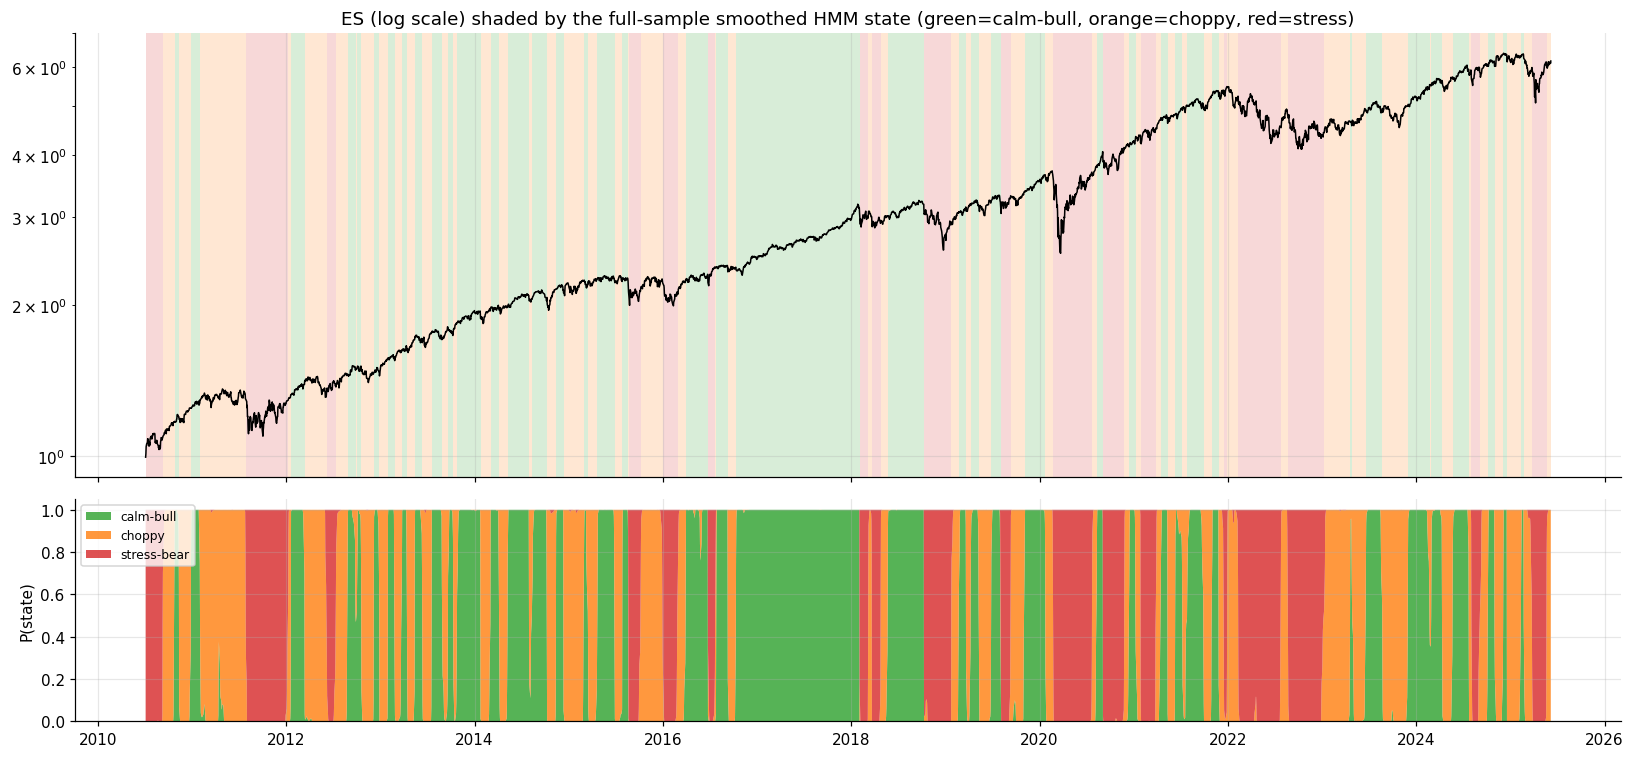

Transition matrix (rows: from, cols: to):


,calm-bull,choppy,stress-bear
calm-bull,0.973,0.024,0.003
choppy,0.030,0.961,0.009
stress-bear,0.000,0.020,0.980


In [4]:
COLORS = {"calm-bull": "#2ca02c", "choppy": "#ff7f0e", "stress-bear": "#d62728"}

def shade(ax, states, alpha=0.18):
    s = states.values; idx = states.index
    start = 0
    for i in range(1, len(s) + 1):
        if i == len(s) or s[i] != s[start]:
            ax.axvspan(idx[start], idx[min(i, len(s) - 1)], color=COLORS[s[start]], alpha=alpha, lw=0)
            start = i

fig, axs = plt.subplots(2, 1, figsize=(15, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
px = (1 + R.ES).cumprod()
axs[0].semilogy(px.index, px, color="k", lw=1)
shade(axs[0], state_smooth)
axs[0].set_title("ES (log scale) shaded by the full-sample smoothed HMM state (green=calm-bull, orange=choppy, red=stress)")
axs[1].stackplot(post_smooth.index, post_smooth.T.values, colors=[COLORS[l] for l in LABELS], alpha=0.8, labels=LABELS)
axs[1].set_ylabel("P(state)"); axs[1].legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()
print("Transition matrix (rows: from, cols: to):")
pd.DataFrame(hmm_full.transmat_[np.ix_(order, order)], index=LABELS, columns=LABELS)

The HMM recovers textbook regimes without being told about them: the 2011 euro crisis, the 2015–16 China/oil
sell-off, the Feb-2018 "Volmageddon", COVID in 2020, the 2022 bear market and the April-2025 tariff shock all
show up as stress. Note the **correlation flip**: in stress, stocks and bonds decorrelate or hedge each other
(though 2022 was the painful exception, when both fell), and this is exactly why the optimal portfolio should
differ by regime.

## 4. The look-ahead trap: smoothed vs filtered probabilities
We now run the forward algorithm ourselves to get the **filtered** $P(s_t\mid x_{1:t})$ with the same parameters,
and compare the two. Even with parameters held fixed, smoothing uses tomorrow's data to relabel today.

filtered and smoothed labels agree on 93.6% of days; median delay before the filter confirms a stress regime: 2 days


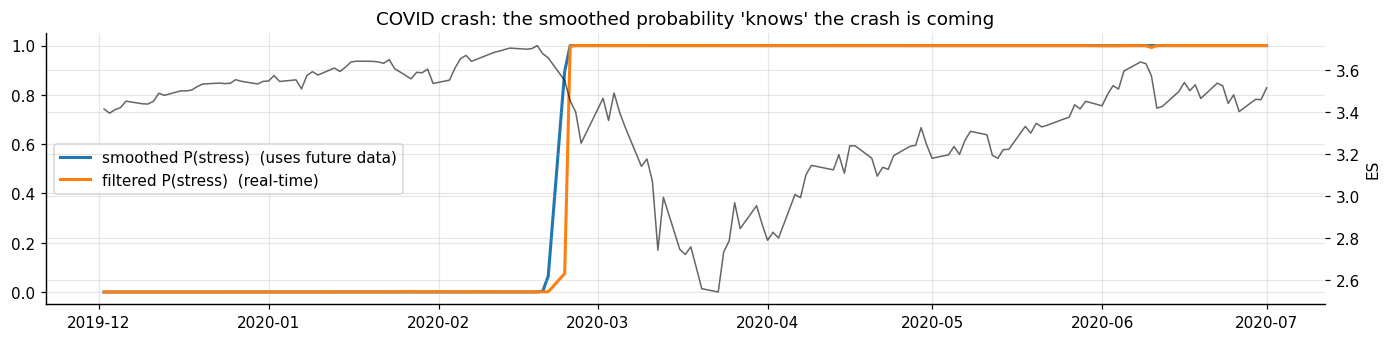

In [5]:
def filtered_probs(model, X):
    """Forward algorithm in log space. Returns P(s_t | x_1..x_t) for every t."""
    K = model.n_components
    logB = np.column_stack([multivariate_normal(model.means_[k], model.covars_[k]).logpdf(X) for k in range(K)])
    logA = np.log(model.transmat_)
    la = np.log(model.startprob_ + 1e-300) + logB[0]
    out = np.empty_like(logB)
    out[0] = la - logsumexp(la)
    for t in range(1, len(X)):
        la = logB[t] + logsumexp(out[t - 1][:, None] + logA, axis=0)
        out[t] = la - logsumexp(la)
    return np.exp(out)


post_filt = pd.DataFrame(filtered_probs(hmm_full, X_all)[:, order], index=FEAT.index, columns=LABELS)
state_filt = post_filt.idxmax(axis=1)
agree = (state_filt == state_smooth).mean()
lag = []
for lab in ["stress-bear"]:
    s_on = state_smooth.eq(lab) & ~state_smooth.shift().eq(lab)
    for d in s_on[s_on].index:
        f = state_filt.loc[d:].eq(lab)
        lag.append(np.argmax(f.values) if f.any() else np.nan)
print(f"filtered and smoothed labels agree on {agree:.1%} of days;"
      f" median delay before the filter confirms a stress regime: {np.nanmedian(lag):.0f} days")

fig, ax = plt.subplots(figsize=(15, 3.2))
w = slice("2019-12-01", "2020-07-01")
ax.plot(post_smooth.loc[w, "stress-bear"], label="smoothed P(stress)  (uses future data)", lw=2)
ax.plot(post_filt.loc[w, "stress-bear"], label="filtered P(stress)  (real-time)", lw=2)
ax2 = ax.twinx(); ax2.plot(px.loc[w], color="k", lw=1, alpha=.6); ax2.set_ylabel("ES")
ax.legend(loc="center left"); ax.set_title("COVID crash: the smoothed probability 'knows' the crash is coming"); plt.show()

## 5. Walk-forward regime detection
For a genuine back-test, *everything* (feature scaling, HMM parameters, state labelling, optimiser inputs) must
come from data available at the time:
* burn-in: first 4 years (2010-07 → 2014-06);
* **re-fit the HMM every 6 months** on an expanding window, re-label states by volatility;
* between re-fits, update the **filtered** probabilities day by day with the forward recursion.

In [6]:
REFIT = pd.date_range("2014-07-01", FEAT.index[-1], freq="6MS")
probs_wf = []
models_wf = {}
t0 = time.time()
for i, d0 in enumerate(REFIT):
    d1 = REFIT[i + 1] if i + 1 < len(REFIT) else FEAT.index[-1] + pd.Timedelta(days=1)
    train = FEAT[FEAT.index < d0]
    m_, s_ = train.mean(), train.std()
    model, od = fit_hmm(((train - m_) / s_).values, seeds=(0, 1, 2))
    models_wf[d0] = (model, od, m_, s_)
    # run the filter over train + out-of-sample block, keep only the out-of-sample part
    block = FEAT[FEAT.index < d1]
    p = filtered_probs(model, ((block - m_) / s_).values)[:, od]
    probs_wf.append(pd.DataFrame(p, index=block.index, columns=LABELS).loc[d0:])
P = pd.concat(probs_wf)
P = P[~P.index.duplicated()]
print(f"{len(REFIT)} re-fits in {time.time()-t0:.0f}s; out-of-sample days: {len(P):,}")
P.idxmax(axis=1).value_counts(normalize=True)

22 re-fits in 42s; out-of-sample days: 2,832


calm-bull     0.350
choppy        0.334
stress-bear   0.316
Name: proportion, dtype: float64

## 6. Regime-dependent optimisers
Each rebalance date (weekly, Friday close → trade Monday), with a trailing 1-year EWMA covariance $\hat\Sigma$
(half-life 63 days) and long-only, fully-invested weights with a 50 % cap per asset:

| Regime | Criterion | Why |
|---|---|---|
| calm-bull | **max Sharpe** with $\hat\mu$ = regime-conditional mean returns from the training window | trends persist in calm markets, so take equity risk |
| choppy | **risk parity** (equal risk contribution) | no reliable return view, so diversify risk |
| stress-bear | **minimum variance** | preserve capital; estimated means are unreliable in crashes |

Two ways to combine them:
* **Hard switch**: use the criterion of the most likely filtered state. To avoid whipsaw we only switch when that
  state's probability exceeds 0.6 (hysteresis).
* **Soft blend**: the probability-weighted average of the three regime portfolios, which is smoother and has less turnover.

The regime-conditional means $\hat\mu_k$ are estimated from the training window, weighting each day by its
*smoothed* state probability. That's legitimate here, because it only uses data inside the training window.

In [7]:
def ewma_cov(Rw, halflife=63):
    w = 0.5 ** (np.arange(len(Rw))[::-1] / halflife); w /= w.sum()
    X = Rw.values - (w[:, None] * Rw.values).sum(0)
    return (X * w[:, None]).T @ X


def max_sharpe(mu, S, cap=0.5):
    n = len(mu)
    if np.all(mu <= 0):
        return min_var(S, cap)
    y = cp.Variable(n)                     # Cornuejols–Tütüncü transformation: w = y / sum(y)
    k = cp.Variable()
    cons = [mu @ y == 1, y >= 0, cp.sum(y) == k, y <= cap * k, k >= 0]
    cp.Problem(cp.Minimize(cp.quad_form(y, cp.psd_wrap(S))), cons).solve(solver=cp.CLARABEL)
    w = np.maximum(y.value, 0); return w / w.sum()


def min_var(S, cap=0.5):
    w = cp.Variable(S.shape[0])
    cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(S))), [cp.sum(w) == 1, w >= 0, w <= cap]).solve(solver=cp.CLARABEL)
    return np.maximum(w.value, 0) / np.maximum(w.value, 0).sum()


def risk_parity(S):
    """Spinu (2013) convex formulation: min 0.5 y'Sy - sum log y, then normalise."""
    y = cp.Variable(S.shape[0])
    cp.Problem(cp.Minimize(0.5 * cp.quad_form(y, cp.psd_wrap(S)) - cp.sum(cp.log(y)))).solve(solver=cp.CLARABEL)
    return y.value / y.value.sum()


def regime_means(d0):
    """Regime-conditional mean returns from the training window of the model in force at d0."""
    key = max(k for k in models_wf if k <= d0)
    model, od, m_, s_ = models_wf[key]
    train = FEAT[FEAT.index < key]
    sm_ = model.predict_proba(((train - m_) / s_).values)[:, od]
    Rt = R.loc[train.index]
    return np.array([(sm_[:, k:k + 1] * Rt.values).sum(0) / sm_[:, k].sum() for k in range(3)])


REB = P.index[P.index.dayofweek == 4]           # Fridays
W = {k: [] for k in ["hard switch", "soft blend", "equal weight", "static risk parity", "static min-var",
                     "static max-Sharpe", "60/40 ES/ZN"]}
regime_used, prev = [], "choppy"
cache_mu = {}
t0 = time.time()
for d in REB:
    hist = R[R.index <= d].iloc[-252:]
    S = ewma_cov(hist) * 252
    key = max(k for k in models_wf if k <= d)
    if key not in cache_mu:
        cache_mu[key] = regime_means(d) * 252
    MU = cache_mu[key]
    w_bull, w_chop, w_bear = max_sharpe(MU[0], S), risk_parity(S), min_var(S)
    p = P.loc[d].values
    top = LABELS[int(np.argmax(p))]
    if p.max() > 0.6:
        prev = top
    regime_used.append(prev)
    W["hard switch"].append({"calm-bull": w_bull, "choppy": w_chop, "stress-bear": w_bear}[prev])
    W["soft blend"].append(p[0] * w_bull + p[1] * w_chop + p[2] * w_bear)
    W["equal weight"].append(np.ones(len(ASSETS)) / len(ASSETS))
    W["static risk parity"].append(w_chop)
    W["static min-var"].append(w_bear)
    mu_all = R[R.index < key].mean().values * 252                  # full training-window mean
    W["static max-Sharpe"].append(max_sharpe(mu_all, S))
    W["60/40 ES/ZN"].append(np.array([0.6, 0, 0.4, 0, 0, 0]))
W = {k: pd.DataFrame(v, index=REB, columns=ASSETS) for k, v in W.items()}
regime_used = pd.Series(regime_used, index=REB)
print(f"optimised {len(REB)} weekly rebalances × 4 optimisers in {time.time()-t0:.0f}s")

optimised 553 weekly rebalances × 4 optimisers in 10s


## 7. Back-test
Weights decided at Friday's close are held from Monday. Costs: **2 bp per unit of turnover** (a conservative
all-in figure for liquid futures, covering half-spread, commissions and roll slippage). Because risk parity and
min-variance load up on low-vol bonds, raw portfolios differ a lot in risk. To compare *skill* rather than
*leverage*, every strategy is also shown **vol-targeted to 10 %** using its own trailing 63-day realised vol
(lagged, so no look-ahead, and capped at 4× leverage).

In [8]:
COST = 2e-4


def backtest(Wk, target_vol=None):
    w = Wk.reindex(R.index).ffill().shift(1).loc[Wk.index[0]:].dropna()    # trade the day after the decision
    gross = (w * R.loc[w.index]).sum(1)
    turn = w.diff().abs().sum(1).fillna(0)
    net = gross - COST * turn
    if target_vol:
        rv = net.rolling(63).std().shift(1) * np.sqrt(252)
        lev = (target_vol / rv).clip(upper=4).fillna(1)
        net = lev * net - COST * lev.diff().abs().fillna(0) * 0.5
    return net, turn


def stats(r, turn=None):
    eq = (1 + r).cumprod(); dd = eq / eq.cummax() - 1
    yrs = len(r) / 252
    out = {"CAGR": eq.iloc[-1] ** (1 / yrs) - 1, "vol": r.std() * np.sqrt(252),
           "Sharpe": r.mean() / r.std() * np.sqrt(252), "max DD": dd.min(),
           "Calmar": (eq.iloc[-1] ** (1 / yrs) - 1) / -dd.min(), "worst month": r.resample("ME").sum().min()}
    if turn is not None:
        out["turnover/yr"] = turn.sum() / yrs
    return out


RET, RET_VT, TURN = {}, {}, {}
for k, Wk in W.items():
    RET[k], TURN[k] = backtest(Wk)
    RET_VT[k], _ = backtest(Wk, target_vol=0.10)
print("Raw (fully-invested, unlevered) portfolios")
display(pd.DataFrame({k: stats(RET[k], TURN[k]) for k in W}).T.sort_values("Sharpe", ascending=False))
print("Vol-targeted to 10 %")
pd.DataFrame({k: stats(RET_VT[k]) for k in W}).T.sort_values("Sharpe", ascending=False)

Raw (fully-invested, unlevered) portfolios


,CAGR,vol,Sharpe,max DD,Calmar,worst month,turnover/yr
60/40 ES/ZN,0.061,0.103,0.625,-0.208,0.293,-0.070,0.000
equal weight,0.046,0.078,0.613,-0.221,0.206,-0.070,0.000
static max-Sharpe,0.041,0.092,0.482,-0.247,0.166,-0.077,3.563
static risk parity,0.022,0.061,0.390,-0.220,0.100,-0.061,0.915
hard switch,0.020,0.067,0.327,-0.235,0.085,-0.051,8.000
soft blend,0.017,0.067,0.292,-0.236,0.073,-0.051,8.051
static min-var,0.002,0.050,0.065,-0.236,0.008,-0.051,1.318


Vol-targeted to 10 %


,CAGR,vol,Sharpe,max DD,Calmar,worst month
static max-Sharpe,0.068,0.110,0.660,-0.241,0.284,-0.095
60/40 ES/ZN,0.064,0.111,0.618,-0.189,0.340,-0.099
equal weight,0.060,0.107,0.595,-0.249,0.240,-0.082
hard switch,0.047,0.108,0.482,-0.368,0.128,-0.086
static risk parity,0.046,0.106,0.478,-0.333,0.138,-0.091
soft blend,0.044,0.107,0.453,-0.373,0.117,-0.086
static min-var,0.016,0.105,0.201,-0.439,0.036,-0.087


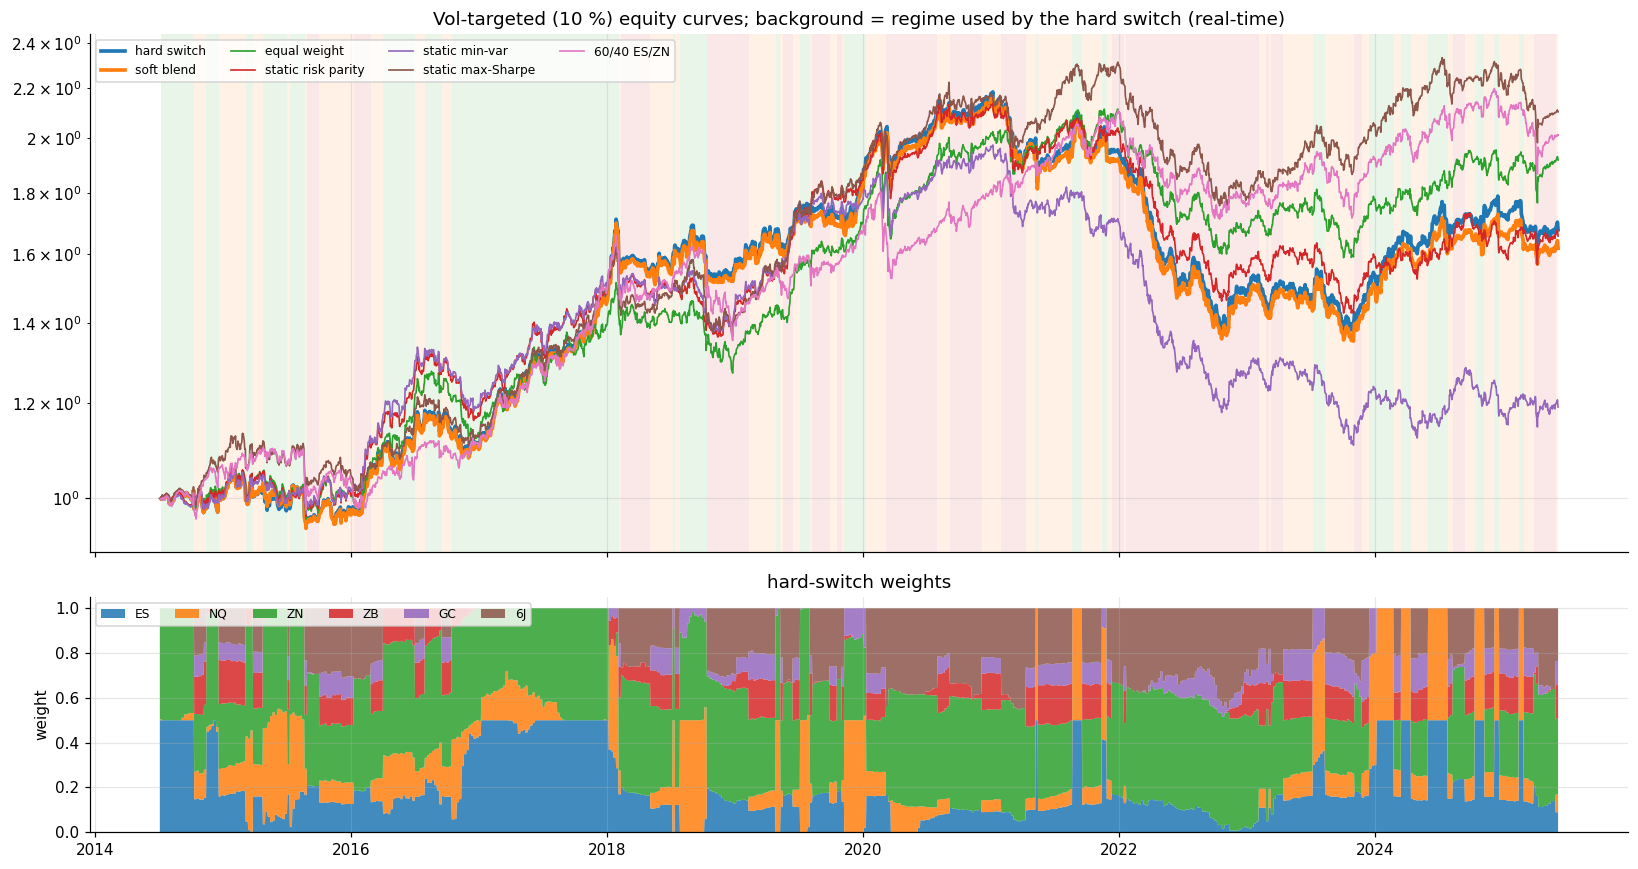

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
for k, c in zip(RET_VT, plt.cm.tab10.colors):
    eq = (1 + RET_VT[k]).cumprod()
    axs[0].semilogy(eq.index, eq, label=k, color=c, lw=2.4 if k in ("hard switch", "soft blend") else 1.1)
shade(axs[0], regime_used.reindex(RET_VT["hard switch"].index).ffill().bfill(), alpha=0.10)
axs[0].legend(ncol=4, fontsize=8); axs[0].set_title("Vol-targeted (10 %) equity curves; background = regime used by the hard switch (real-time)")
Wh = W["hard switch"].reindex(R.loc[W["hard switch"].index[0]:].index).ffill()
axs[1].stackplot(Wh.index, Wh.T.values, labels=ASSETS, alpha=.85)
axs[1].set_ylabel("weight"); axs[1].legend(ncol=6, fontsize=8, loc="upper left"); axs[1].set_title("hard-switch weights")
plt.tight_layout(); plt.show()

### 7.1 Sub-periods and a significance check
Regime strategies are meant to earn their keep in drawdowns. We look at calendar sub-periods and bootstrap the
difference in Sharpe ratio between the regime strategy and its closest static twin (static risk parity), with a
stationary block bootstrap (Politis–Romano, mean block of 21 days) that preserves volatility clustering.

In [10]:
periods = {"2014H2-2019": ("2014-07-01", "2019-12-31"), "2020 (COVID)": ("2020-01-01", "2020-12-31"),
           "2021": ("2021-01-01", "2021-12-31"), "2022 (stock+bond bear)": ("2022-01-01", "2022-12-31"),
           "2023-2025H1": ("2023-01-01", "2025-06-30")}
sub = pd.DataFrame({p: {k: stats(RET_VT[k].loc[a:b])["Sharpe"] for k in RET_VT} for p, (a, b) in periods.items()})
display(sub.style.format("{:.2f}").background_gradient(cmap="RdYlGn", axis=0))


def block_bootstrap_sharpe_diff(a, b, n=2000, block=21, seed=0):
    rng = np.random.default_rng(seed)
    x = np.column_stack([a.values, b.values]); T = len(x)
    diffs = []
    for _ in range(n):
        idx = []
        while len(idx) < T:
            s = rng.integers(T); L = rng.geometric(1 / block)
            idx.extend(range(s, min(s + L, T)))
        xx = x[idx[:T]]
        sr = xx.mean(0) / xx.std(0) * np.sqrt(252)
        diffs.append(sr[0] - sr[1])
    return np.array(diffs)


for strat in ["hard switch", "soft blend"]:
    a, b = RET_VT[strat].align(RET_VT["static risk parity"], join="inner")
    d = block_bootstrap_sharpe_diff(a, b)
    print(f"{strat:12s} − static risk parity: ΔSharpe = {stats(a)['Sharpe'] - stats(b)['Sharpe']:+.2f}, "
          f"bootstrap 90% CI [{np.percentile(d, 5):+.2f}, {np.percentile(d, 95):+.2f}],  P(Δ>0) = {(d > 0).mean():.0%}")

,2014H2-2019,2020 (COVID),2021,2022 (stock+bond bear),2023-2025H1
hard switch,1.08,1.58,-0.88,-2.28,0.51
soft blend,1.05,1.61,-0.94,-2.29,0.45
equal weight,0.97,1.35,0.44,-1.92,0.58
static risk parity,1.12,1.22,-0.42,-2.24,0.33
static min-var,1.06,0.90,-1.29,-2.38,-0.19
static max-Sharpe,1.09,1.32,0.53,-2.02,0.66
60/40 ES/ZN,0.89,0.67,1.42,-1.48,0.54


hard switch  − static risk parity: ΔSharpe = +0.00, bootstrap 90% CI [-0.30, +0.30],  P(Δ>0) = 50%


soft blend   − static risk parity: ΔSharpe = -0.03, bootstrap 90% CI [-0.32, +0.27],  P(Δ>0) = 44%


### 7.2 Interpretation (what this back-test actually shows)
* **The HMM finds real regimes, but the regimes here are volatility regimes, not return regimes.** In the full-sample
  fit the "stress" state has near-zero average equity return and 3× the volatility of the calm state. That's useful for
  risk management but says little about direction.
* **Where the switch helped: COVID-2020.** The filter confirmed stress within a couple of days (median delay above).
  Rotating into minimum variance and then back into max-Sharpe gave the regime strategies the best 2020 Sharpe of any
  portfolio, far above 60/40.
* **Where it hurt: 2021–2022.** The defensive allocations (min-var, risk parity) are dominated by Treasuries and the yen, the
  assets with the lowest volatility *in the training data*. When inflation arrived, bonds, not stocks, became the risk. The
  stock–bond correlation turned positive, and the "safe" portfolio lost as much as the risky one. A model trained on
  2010–2020 had never seen that regime, so no amount of filtering could anticipate it.
* **Net result: roughly a tie with static risk parity** (ΔSharpe ≈ 0, bootstrap 90 % interval about ±0.3), and behind the
  equity-heavy static portfolios, because equities had an exceptional decade. Turnover is ~8× per year versus <1× for
  static risk parity, so the switch has to earn its costs, and here it only just does.
* **Statistical power is low.** 11 years with a handful of distinct stress episodes can't separate Sharpe differences of a few
  tenths from zero. Treat regime back-tests that claim otherwise with suspicion, especially ones based on smoothed probabilities.

**Lesson:** a regime model is only as good as the mapping from *regime* to *portfolio*. Here that mapping ("in stress, buy what
was low-vol") is itself a stationarity assumption, and it broke in 2022. Better mappings condition on the stock–bond correlation
or on inflation regimes, or use regime-conditional moments estimated with shrinkage rather than fixed criteria.

## 8. Strengths, weaknesses, extensions
**Strengths**
* HMMs give interpretable, probabilistic regimes with persistence (transition matrix) and a principled online update.
* State-conditional moments capture the *correlation* regime change (stocks vs bonds), which a single covariance matrix averages away.
* The soft blend turns regime uncertainty directly into smoother portfolios and lower turnover.

**Weaknesses**
* **Detection lag**: filtered probabilities react after the fact; the smoothed ones that look so good are not available in real time.
* **Label switching / instability**: re-fitted HMMs can permute or redefine states. We re-label by volatility, which
  works for 3 states but is a heuristic.
* **Gaussian emissions** understate crash tails; the number of states is a modelling choice (use BIC or a held-out likelihood).
* **Estimation error** in regime-conditional means, especially for rare stress states, feeds straight into max-Sharpe.
* **Stationarity**: the stock–bond correlation flipped sign in 2022 after two decades, and a model trained pre-2021
  couldn't know that.

**Extensions**
* Student-t or mixture emissions; HSMM (explicit duration distributions); Markov-switching VAR (Hamilton).
* Add macro inputs (yield-curve slope, credit spreads, VIX term structure from `data_cache/yahoo_index_levels.parquet`).
* Replace the regime-to-criterion map with regime-conditional **robust** optimisation (Black–Litterman with regime views, or CVaR).
* A statistical-jump model (Nystrup et al. 2020) as a more persistent alternative to HMMs.

**References.** Hamilton (1989); Ang & Bekaert, "International asset allocation with regime shifts", *RFS* (2002);
Nystrup, Madsen & Lindström, "Dynamic portfolio optimization across hidden market regimes", *Quant. Finance* (2018);
Spinu (2013) for convex risk parity; Rabiner (1989) HMM tutorial.